In [6]:
#rascunho de análises e cálculos
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
con = duckdb.connect(database=':memory:')

In [8]:
products = r"SEU CAMINHO"
products_missing = r"SEU CAMINHO"
data_customers = r"SEU CAMINHO"
data_drivers = r"SEU CAMINHO"
orders = r"SEU CAMINHO"


In [9]:
con.sql(f"CREATE VIEW products as SELECT * FROM '{products}'")
con.sql(f"CREATE VIEW products_missing as SELECT * FROM '{products_missing}'")
con.sql(f"CREATE VIEW data_customers as SELECT * FROM '{data_customers}'")
con.sql(f"CREATE VIEW data_drivers as SELECT * FROM '{data_drivers}'")
con.sql(f"CREATE VIEW orders as SELECT * FROM '{orders}'")

In [10]:
query_itens_perdidos = """
    WITH devolucoes_limpas AS (
        SELECT 
            order_id,
            UNNEST([product_id_1, product_id_2, product_id_3]) AS product_id
        FROM products_missing
    ),
    
    produtos_limpos AS (
        SELECT 
            produc_id AS product_id, 
            product_name,
            CAST(REPLACE(price, '$', '') AS DOUBLE) AS price
        FROM products
    )
    
    SELECT 
        p.product_name,
        COUNT(d.product_id) AS total_devolucoes,
        SUM(p.price) AS prejuizo_total
    FROM devolucoes_limpas d
    JOIN produtos_limpos p ON d.product_id = p.product_id
    WHERE d.product_id IS NOT NULL AND d.product_id != ''
    GROUP BY p.product_name
    ORDER BY total_devolucoes DESC
    LIMIT 20
"""

con.sql(query_itens_perdidos).show()

┌───────────────────────┬──────────────────┬────────────────────┐
│     product_name      │ total_devolucoes │   prejuizo_total   │
│        varchar        │      int64       │       double       │
├───────────────────────┼──────────────────┼────────────────────┤
│ Ground Coffee         │               19 │             252.32 │
│ Chicken Breast        │               19 │ 112.67000000000004 │
│ Cheddar Cheese        │               18 │             224.46 │
│ Frozen Shrimp         │               17 │  80.06999999999998 │
│ Peanut Butter         │               17 │ 328.43999999999994 │
│ Uncured Bacon         │               17 │  79.39000000000001 │
│ Canned Tuna           │               17 │ 316.20000000000005 │
│ Rice Cakes            │               16 │ 104.96000000000002 │
│ Turkey Burgers        │               16 │ 135.68000000000004 │
│ Cinnamon Toast Crunch │               15 │ 121.64999999999999 │
│ Kellogg's Frosties    │               15 │             187.95 │
│ Oat Milk

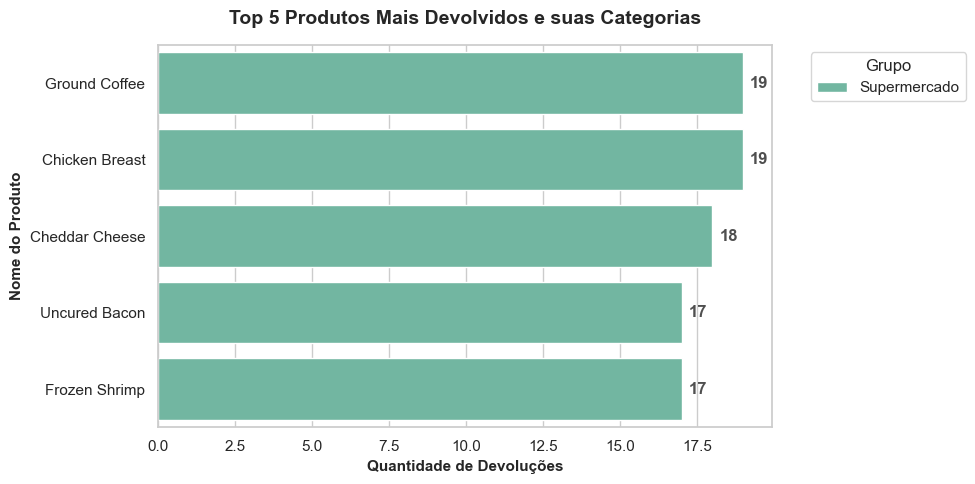

In [11]:
query_grafico = """
    WITH devolucoes_limpas AS (
        SELECT 
            order_id,
            UNNEST([product_id_1, product_id_2, product_id_3]) AS product_id
        FROM products_missing
    ),
    produtos_limpos AS (
        SELECT 
            produc_id AS product_id,
            product_name,
        FROM products
    )
    SELECT 
        p.product_name,
        p.category,
        COUNT(d.product_id) AS total_devolucoes
    FROM devolucoes_limpas d
    JOIN produtos_limpos p ON d.product_id = p.product_id
    WHERE d.product_id IS NOT NULL AND d.product_id != ''
    GROUP BY p.product_name, p.category
    ORDER BY total_devolucoes DESC
    LIMIT 5 -- Filtra apenas os 5 primeiros
"""

df_top5 = con.sql(query_grafico).df()

sns.set_theme(style="whitegrid") 
plt.figure(figsize=(10, 5))      

ax = sns.barplot(
    x="total_devolucoes", 
    y="product_name", 
    hue="category", 
    data=df_top5,
    palette="Set2",          
    dodge=False              
)


plt.title("Top 5 Produtos Mais Devolvidos e suas Categorias", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quantidade de Devoluções", fontsize=11, fontweight='bold')
plt.ylabel("Nome do Produto", fontsize=11, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5, fontweight='bold', color='#4f4f4f')
plt.legend(title="Grupo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

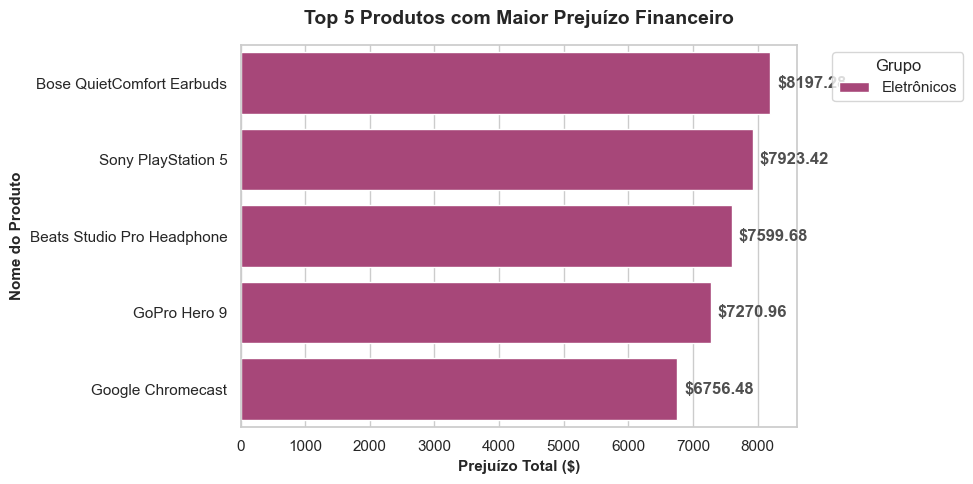

In [12]:
query_grafico_valor = """
    WITH devolucoes_limpas AS (
        SELECT 
            order_id,
            UNNEST([product_id_1, product_id_2, product_id_3]) AS product_id
        FROM products_missing
    ),
    produtos_limpos AS (
        SELECT 
            produc_id AS product_id,
            product_name,
            category,
            CAST(REPLACE(price, '$', '') AS DOUBLE) AS price
        FROM products
    )
    SELECT 
        p.product_name,
        p.category,
        SUM(p.price) AS prejuizo_total -- Somando o preço para ver o impacto financeiro
    FROM devolucoes_limpas d
    JOIN produtos_limpos p ON d.product_id = p.product_id
    WHERE d.product_id IS NOT NULL AND d.product_id != ''
    GROUP BY p.product_name, p.category
    ORDER BY prejuizo_total DESC -- Ordenando pelo maior prejuízo
    LIMIT 5
"""


df_top5_valor = con.sql(query_grafico_valor).df()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x="prejuizo_total", 
    y="product_name", 
    hue="category", 
    data=df_top5_valor,
    palette="magma",        
    dodge=False
)
plt.title("Top 5 Produtos com Maior Prejuízo Financeiro", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Prejuízo Total ($)", fontsize=11, fontweight='bold')
plt.ylabel("Nome do Produto", fontsize=11, fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=5, fontweight='bold', color='#4f4f4f')

plt.legend(title="Grupo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
"""
Para calcular a "TAXA DE PROBLEMAS", 
não basta contar quantos problemas um motorista ou cliente teve,
precisamos dividir isso pelo total de pedidos que cada um realizou. 
Isso evita que motoristas muito ativos sejam injustamente penalizados 
apenas por terem um volume maior de trabalho.
"""



'\nPara calcular a "TAXA DE PROBLEMAS", \nnão basta contar quantos problemas um motorista ou cliente teve,\nprecisamos dividir isso pelo total de pedidos que cada um realizou. \nIsso evita que motoristas muito ativos sejam injustamente penalizados \napenas por terem um volume maior de trabalho.\n'

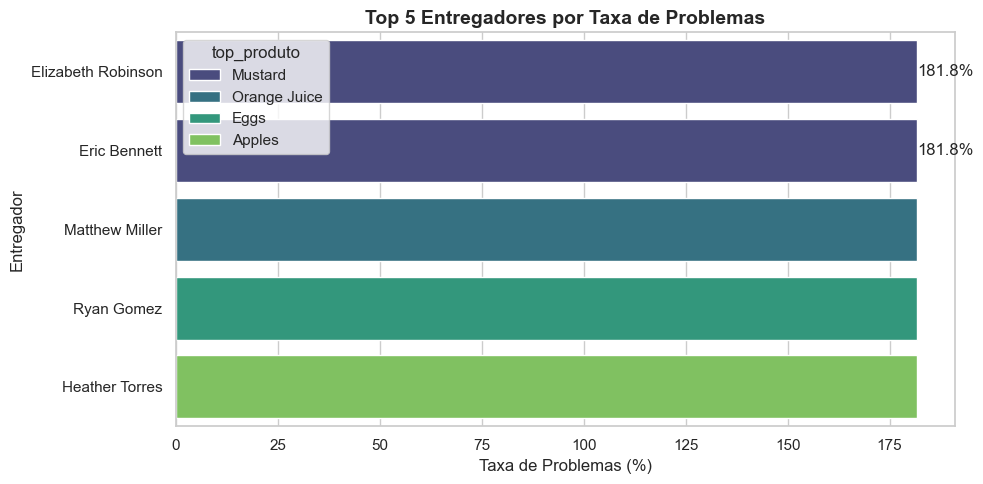

In [14]:
###ENTREGADOR + PROBLEMA
query_entregador_grafico = """
    WITH problemas_por_produto AS (
        SELECT m.order_id, UNNEST([m.product_id_1, m.product_id_2, m.product_id_3]) AS product_id
        FROM products_missing m WHERE m.product_id_1 IS NOT NULL
    ),
    rank_produtos AS (
        SELECT o.driver_id, p.product_name, COUNT(*) as qtd,
               ROW_NUMBER() OVER(PARTITION BY o.driver_id ORDER BY COUNT(*) DESC) as rank
        FROM orders o
        JOIN problemas_por_produto pr ON o.order_id = pr.order_id
        JOIN products p ON pr.product_id = p.produc_id
        GROUP BY o.driver_id, p.product_name
    )
    SELECT d.driver_name, 
           ROUND(100.0 * COUNT(m.order_id) / COUNT(DISTINCT o.order_id), 2) AS taxa,
           MAX(CASE WHEN r.rank = 1 THEN r.product_name END) AS top_produto
    FROM orders o
    LEFT JOIN products_missing m ON o.order_id = m.order_id
    JOIN data_drivers d ON o.driver_id = d.driver_id
    LEFT JOIN rank_produtos r ON o.driver_id = r.driver_id
    GROUP BY d.driver_name
    HAVING taxa > 0
    ORDER BY taxa DESC
    LIMIT 5
"""

df_d = con.sql(query_entregador_grafico).df()
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="taxa", y="driver_name", hue="top_produto", data=df_d, palette="viridis", dodge=False)
plt.title("Top 5 Entregadores por Taxa de Problemas", fontsize=14, fontweight='bold')
plt.xlabel("Taxa de Problemas (%)")
plt.ylabel("Entregador")
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.tight_layout()
plt.show()

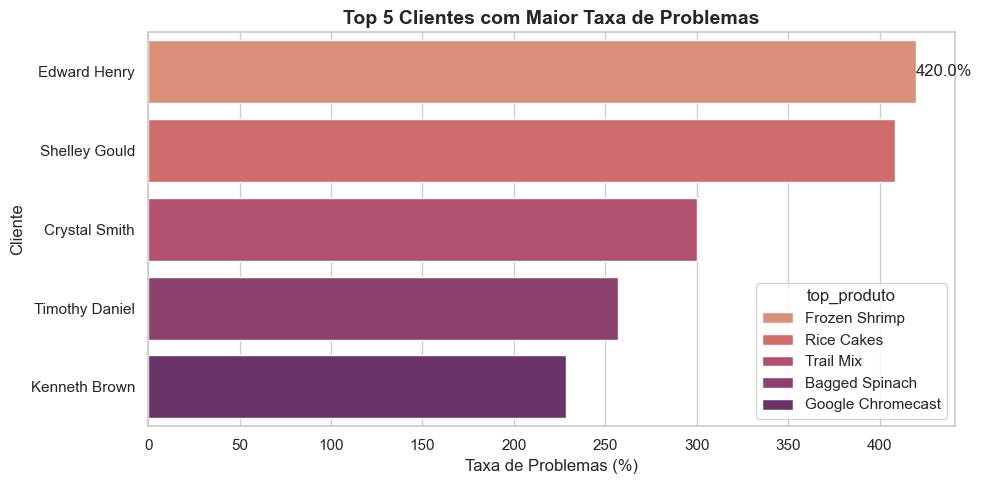

In [15]:
query_cliente_grafico = """
    WITH problemas_por_produto AS (
        SELECT m.order_id, UNNEST([m.product_id_1, m.product_id_2, m.product_id_3]) AS product_id
        FROM products_missing m WHERE m.product_id_1 IS NOT NULL
    ),
    rank_produtos AS (
        SELECT o.customer_id, p.product_name, COUNT(*) as qtd,
               ROW_NUMBER() OVER(PARTITION BY o.customer_id ORDER BY COUNT(*) DESC) as rank
        FROM orders o
        JOIN problemas_por_produto pr ON o.order_id = pr.order_id
        JOIN products p ON pr.product_id = p.produc_id
        GROUP BY o.customer_id, p.product_name
    )
    SELECT c.customer_name, 
           ROUND(100.0 * COUNT(m.order_id) / COUNT(DISTINCT o.order_id), 2) AS taxa,
           MAX(CASE WHEN r.rank = 1 THEN r.product_name END) AS top_produto
    FROM orders o
    LEFT JOIN products_missing m ON o.order_id = m.order_id
    JOIN data_customers c ON o.customer_id = c.customer_id
    LEFT JOIN rank_produtos r ON o.customer_id = r.customer_id
    GROUP BY c.customer_name
    HAVING taxa > 0
    ORDER BY taxa DESC
    LIMIT 5
"""

df_c = con.sql(query_cliente_grafico).df()
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="taxa", y="customer_name", hue="top_produto", data=df_c, palette="flare", dodge=False)
plt.title("Top 5 Clientes com Maior Taxa de Problemas", fontsize=14, fontweight='bold')
plt.xlabel("Taxa de Problemas (%)")
plt.ylabel("Cliente")
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.tight_layout()
plt.show()

In [16]:
"""
Para detectar fraudes reais (tanto de clientes dizendo que não receberam, quanto de entregadores desviando carga), a melhor abordagem na ciência de dados é criar um perfil combinando 3 pilares:

Volume/Frequência: A taxa de problemas é maior que o normal? (Ex: > 15%).

Impacto Financeiro: O prejuízo acumulado por essa pessoa é alto? (Ex: > $100).

Direcionamento (Alvo): Fraudes reais costumam focar em itens de alto valor de revenda. Como você tem a coluna category, podemos verificar se os "sumiços" envolvem Eletrônicos. Perder um saco de arroz é comum; perder fones e celulares repetidamente é fraude.

Algoritmo de Score (0 a 4 Pontos):
+1 Ponto: Se a taxa de problemas for maior que 15%.

+1 Ponto: Se o prejuízo total causado pela pessoa for maior que $100.

+2 Pontos: Se houver sumiço de itens da categoria "Eletrônicos" (peso maior pelo risco do produto).

Interpretação:

Score 0 a 1: Erro operacional comum.

Score 2 a 3: Comportamento suspeito (Requer auditoria leve).

Score 4: Altíssima probabilidade de fraude (Foco da sua análise final!).
"""


'\nPara detectar fraudes reais (tanto de clientes dizendo que não receberam, quanto de entregadores desviando carga), a melhor abordagem na ciência de dados é criar um perfil combinando 3 pilares:\n\nVolume/Frequência: A taxa de problemas é maior que o normal? (Ex: > 15%).\n\nImpacto Financeiro: O prejuízo acumulado por essa pessoa é alto? (Ex: > $100).\n\nDirecionamento (Alvo): Fraudes reais costumam focar em itens de alto valor de revenda. Como você tem a coluna category, podemos verificar se os "sumiços" envolvem Eletrônicos. Perder um saco de arroz é comum; perder fones e celulares repetidamente é fraude.\n\nAlgoritmo de Score (0 a 4 Pontos):\n+1 Ponto: Se a taxa de problemas for maior que 15%.\n\n+1 Ponto: Se o prejuízo total causado pela pessoa for maior que $100.\n\n+2 Pontos: Se houver sumiço de itens da categoria "Eletrônicos" (peso maior pelo risco do produto).\n\nInterpretação:\n\nScore 0 a 1: Erro operacional comum.\n\nScore 2 a 3: Comportamento suspeito (Requer auditoria l

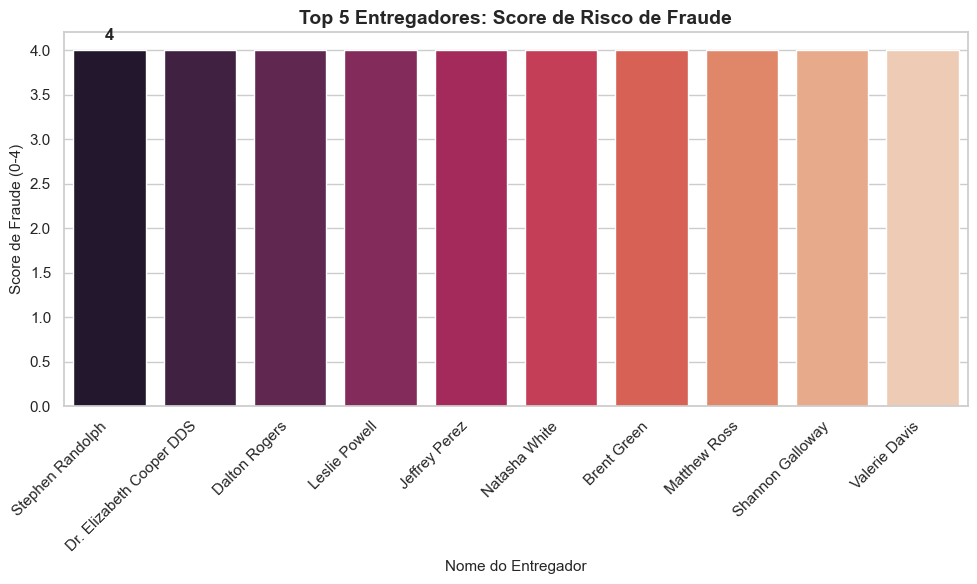

In [17]:
#entregador...

query_score_entregador = """
    WITH problemas_expandidos AS (
        SELECT m.order_id, UNNEST([m.product_id_1, m.product_id_2, m.product_id_3]) AS product_id
        FROM products_missing m WHERE m.product_id_1 IS NOT NULL AND m.product_id_1 != ''
    ),
    detalhes_prejuizo AS (
        SELECT pe.order_id, p.category, CAST(REPLACE(p.price, '$', '') AS DOUBLE) AS price
        FROM problemas_expandidos pe
        JOIN products p ON pe.product_id = p.produc_id
    ),
    resumo_pedidos AS (
        SELECT order_id, SUM(price) AS valor_perdido, 
               SUM(CASE WHEN category = 'Eletrônicos' THEN 1 ELSE 0 END) as qtd_eletronicos
        FROM detalhes_prejuizo GROUP BY order_id
    ),
    perfil_entregador AS (
        SELECT d.driver_name,
            COUNT(DISTINCT o.order_id) AS total_pedidos,
            ROUND(100.0 * COUNT(DISTINCT r.order_id) / COUNT(DISTINCT o.order_id), 2) AS taxa_problema,
            COALESCE(SUM(r.valor_perdido), 0) AS prejuizo_total,
            SUM(COALESCE(r.qtd_eletronicos, 0)) as total_eletronicos_perdidos
        FROM orders o
        JOIN data_drivers d ON o.driver_id = d.driver_id
        LEFT JOIN resumo_pedidos r ON o.order_id = r.order_id
        GROUP BY d.driver_name
    )
    SELECT driver_name, 
           (CASE WHEN taxa_problema > 15 THEN 1 ELSE 0 END) + 
           (CASE WHEN prejuizo_total > 100 THEN 1 ELSE 0 END) +
           (CASE WHEN total_eletronicos_perdidos > 0 THEN 2 ELSE 0 END) AS score_fraude
    FROM perfil_entregador
    WHERE total_pedidos > 3 AND score_fraude > 0
    ORDER BY score_fraude DESC LIMIT 10
"""

df_d_score = con.sql(query_score_entregador).df()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="driver_name", y="score_fraude", data=df_d_score, palette="rocket", hue="driver_name", legend=False)
plt.title("Top 5 Entregadores: Score de Risco de Fraude", fontsize=14, fontweight='bold')
plt.xlabel("Nome do Entregador", fontsize=11)
plt.ylabel("Score de Fraude (0-4)", fontsize=11)
plt.xticks(rotation=45, ha='right') 
ax.bar_label(ax.containers[0], fmt='%.0f', padding=5, fontweight='bold')
plt.tight_layout()
plt.show()

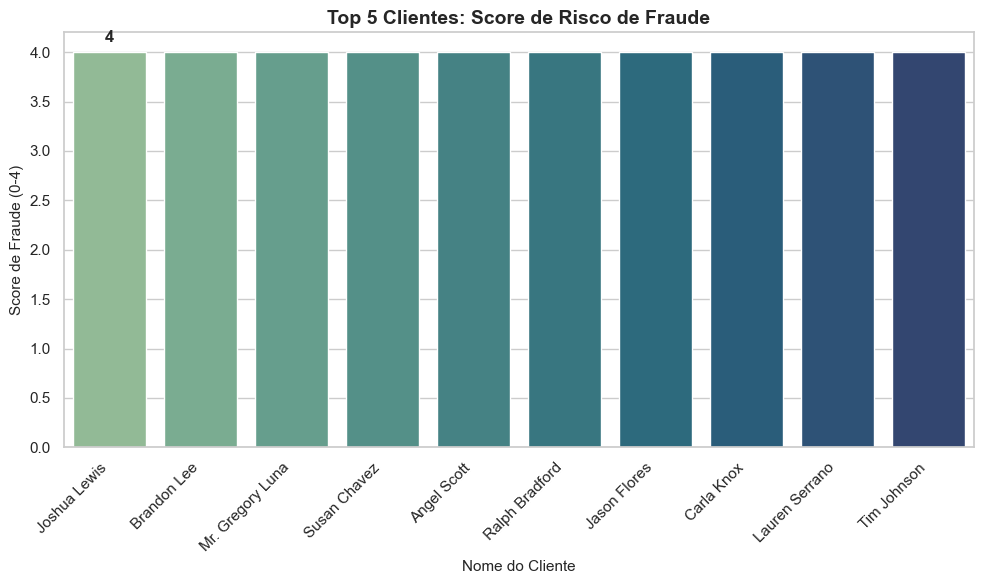

In [18]:
#cliente...
query_score_cliente = """
    WITH problemas_expandidos AS (
        SELECT m.order_id, UNNEST([m.product_id_1, m.product_id_2, m.product_id_3]) AS product_id
        FROM products_missing m WHERE m.product_id_1 IS NOT NULL AND m.product_id_1 != ''
    ),
    detalhes_prejuizo AS (
        SELECT pe.order_id, p.category, CAST(REPLACE(p.price, '$', '') AS DOUBLE) AS price
        FROM problemas_expandidos pe
        JOIN products p ON pe.product_id = p.produc_id
    ),
    resumo_pedidos AS (
        SELECT order_id, SUM(price) AS valor_perdido, 
               SUM(CASE WHEN category = 'Eletrônicos' THEN 1 ELSE 0 END) as qtd_eletronicos
        FROM detalhes_prejuizo GROUP BY order_id
    ),
    perfil_cliente AS (
        SELECT c.customer_name,
            COUNT(DISTINCT o.order_id) AS total_pedidos,
            ROUND(100.0 * COUNT(DISTINCT r.order_id) / COUNT(DISTINCT o.order_id), 2) AS taxa_problema,
            COALESCE(SUM(r.valor_perdido), 0) AS prejuizo_total,
            SUM(COALESCE(r.qtd_eletronicos, 0)) as total_eletronicos_perdidos
        FROM orders o
        JOIN data_customers c ON o.customer_id = c.customer_id
        LEFT JOIN resumo_pedidos r ON o.order_id = r.order_id
        GROUP BY c.customer_name
    )
    SELECT customer_name, 
           (CASE WHEN taxa_problema > 15 THEN 1 ELSE 0 END) + 
           (CASE WHEN prejuizo_total > 100 THEN 1 ELSE 0 END) +
           (CASE WHEN total_eletronicos_perdidos > 0 THEN 2 ELSE 0 END) AS score_fraude
    FROM perfil_cliente
    WHERE total_pedidos > 2 AND score_fraude > 0
    ORDER BY score_fraude DESC LIMIT 10
"""

df_c_score = con.sql(query_score_cliente).df()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="customer_name", y="score_fraude", data=df_c_score, palette="crest", hue="customer_name", legend=False)
plt.title("Top 5 Clientes: Score de Risco de Fraude", fontsize=14, fontweight='bold')
plt.xlabel("Nome do Cliente", fontsize=11)
plt.ylabel("Score de Fraude (0-4)", fontsize=11)
plt.xticks(rotation=45, ha='right')
ax.bar_label(ax.containers[0], fmt='%.0f', padding=5, fontweight='bold')
plt.tight_layout()
plt.show()